In [7]:
import cloudpickle

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [20]:
def plot_results_per_dim(d):
    res_path = f"/home/icb/lorenzo.consoli/repos/scFM_density_estimation/notebooks/rebuttal_estimation_error_effect/out/{d}-dims-2-loc/results.pkl"
    with open(res_path, "rb") as fb:
        results_dict = cloudpickle.load(fb)

    # 1. Extract data and compute MSE
    data = []
    for num_vf_steps, vf_results in results_dict.items():
        for num_score_steps, score_results in vf_results.items():
            
            # Extract the true and predicted values (convert to numpy arrays for vector math)
            y_true = np.array(score_results['log_ratio_true'])
            y_pred = np.array(score_results['log_ratio_hat_v2_scratio']) 
            
            # Calculate Mean Squared Error
            mse = np.mean((y_true - y_pred) ** 2)
            
            # Store in a list of dictionaries
            data.append({
                'num_vf_steps': num_vf_steps,
                'num_score_steps': num_score_steps,
                'MSE': mse
            })

    # Create a DataFrame
    df = pd.DataFrame(data)

    # 2. Pivot the DataFrame to create a 2D matrix for the heatmap
    # columns=x-axis (num_vf_steps), index=y-axis (num_score_steps)
    heatmap_data = df.pivot(index='num_score_steps', columns='num_vf_steps', values='MSE')

    # Sort the y-axis so smaller steps are at the bottom (optional but standard)
    heatmap_data = heatmap_data.sort_index(ascending=False) 

    # 3. Plot the heatmap
    fig, ax = plt.subplots(figsize=(10, 8), dpi=200)
    sns.heatmap(
        heatmap_data, 
        annot=True,          # Shows the MSE values inside the cells
        fmt=".4f",           # Formats the numbers to 4 decimal places
        cmap="magma",      # Color map (viridis, YlGnBu, coolwarm, etc.)
        cbar_kws={'label': 'Mean Squared Error (MSE)'},
        ax=ax
    )

    # 4. Add labels and title
    fig.suptitle(f'MSE Ratios Predictions ({d} Dimensions)')
    ax.set_xlabel('Number of VF Steps')
    ax.set_ylabel('Number of Score Steps')
    fig.tight_layout()
    return fig, ax

2


5
10
20
30


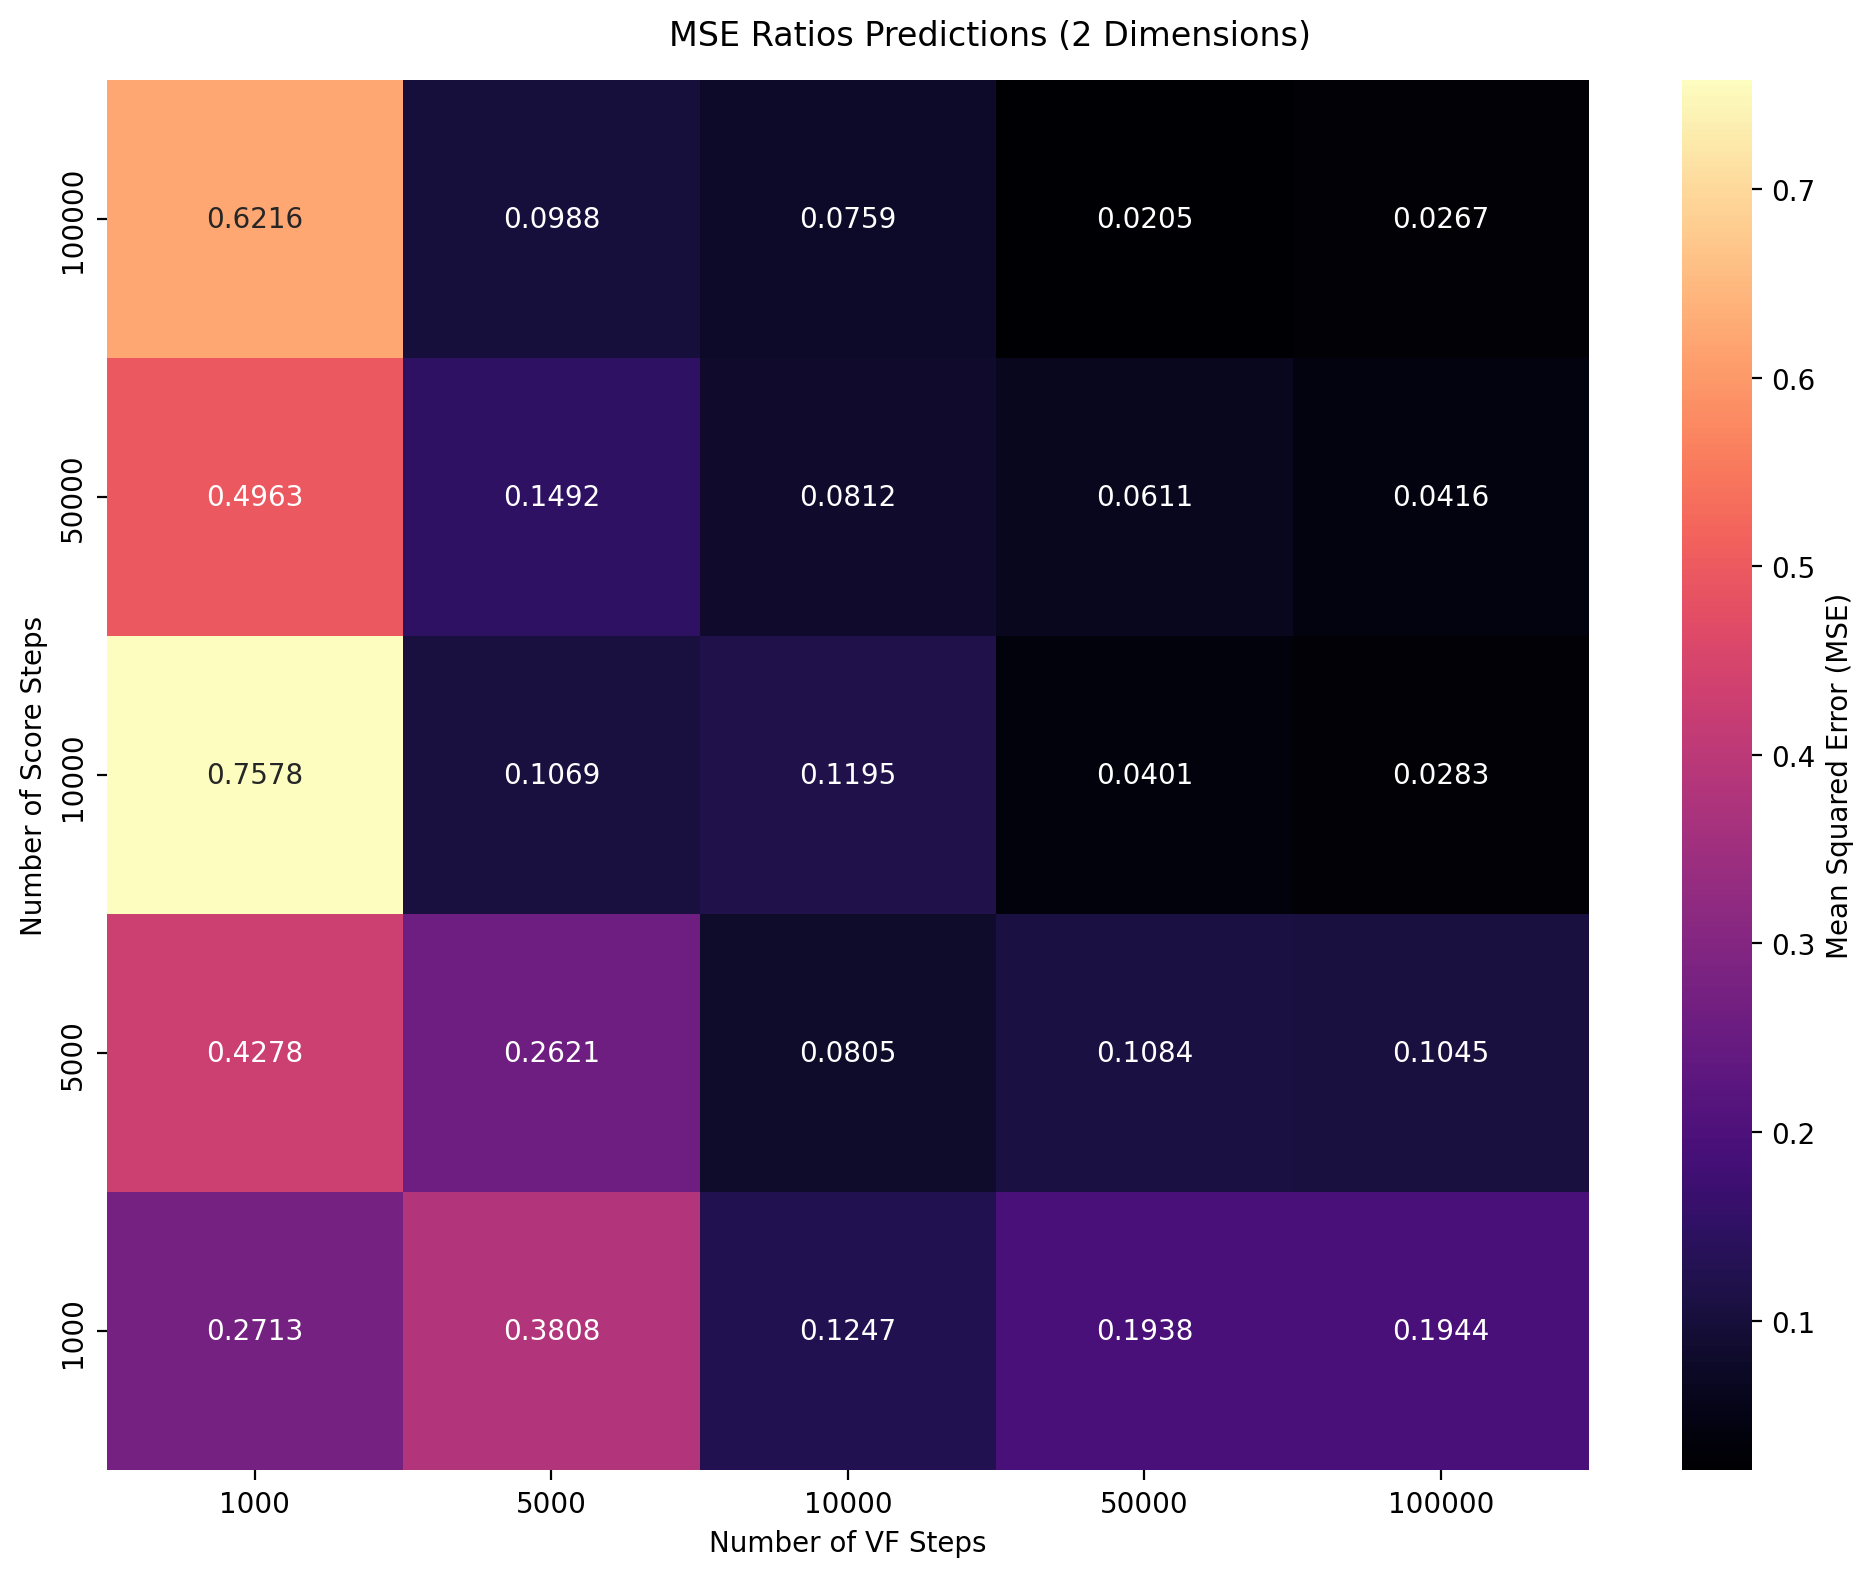

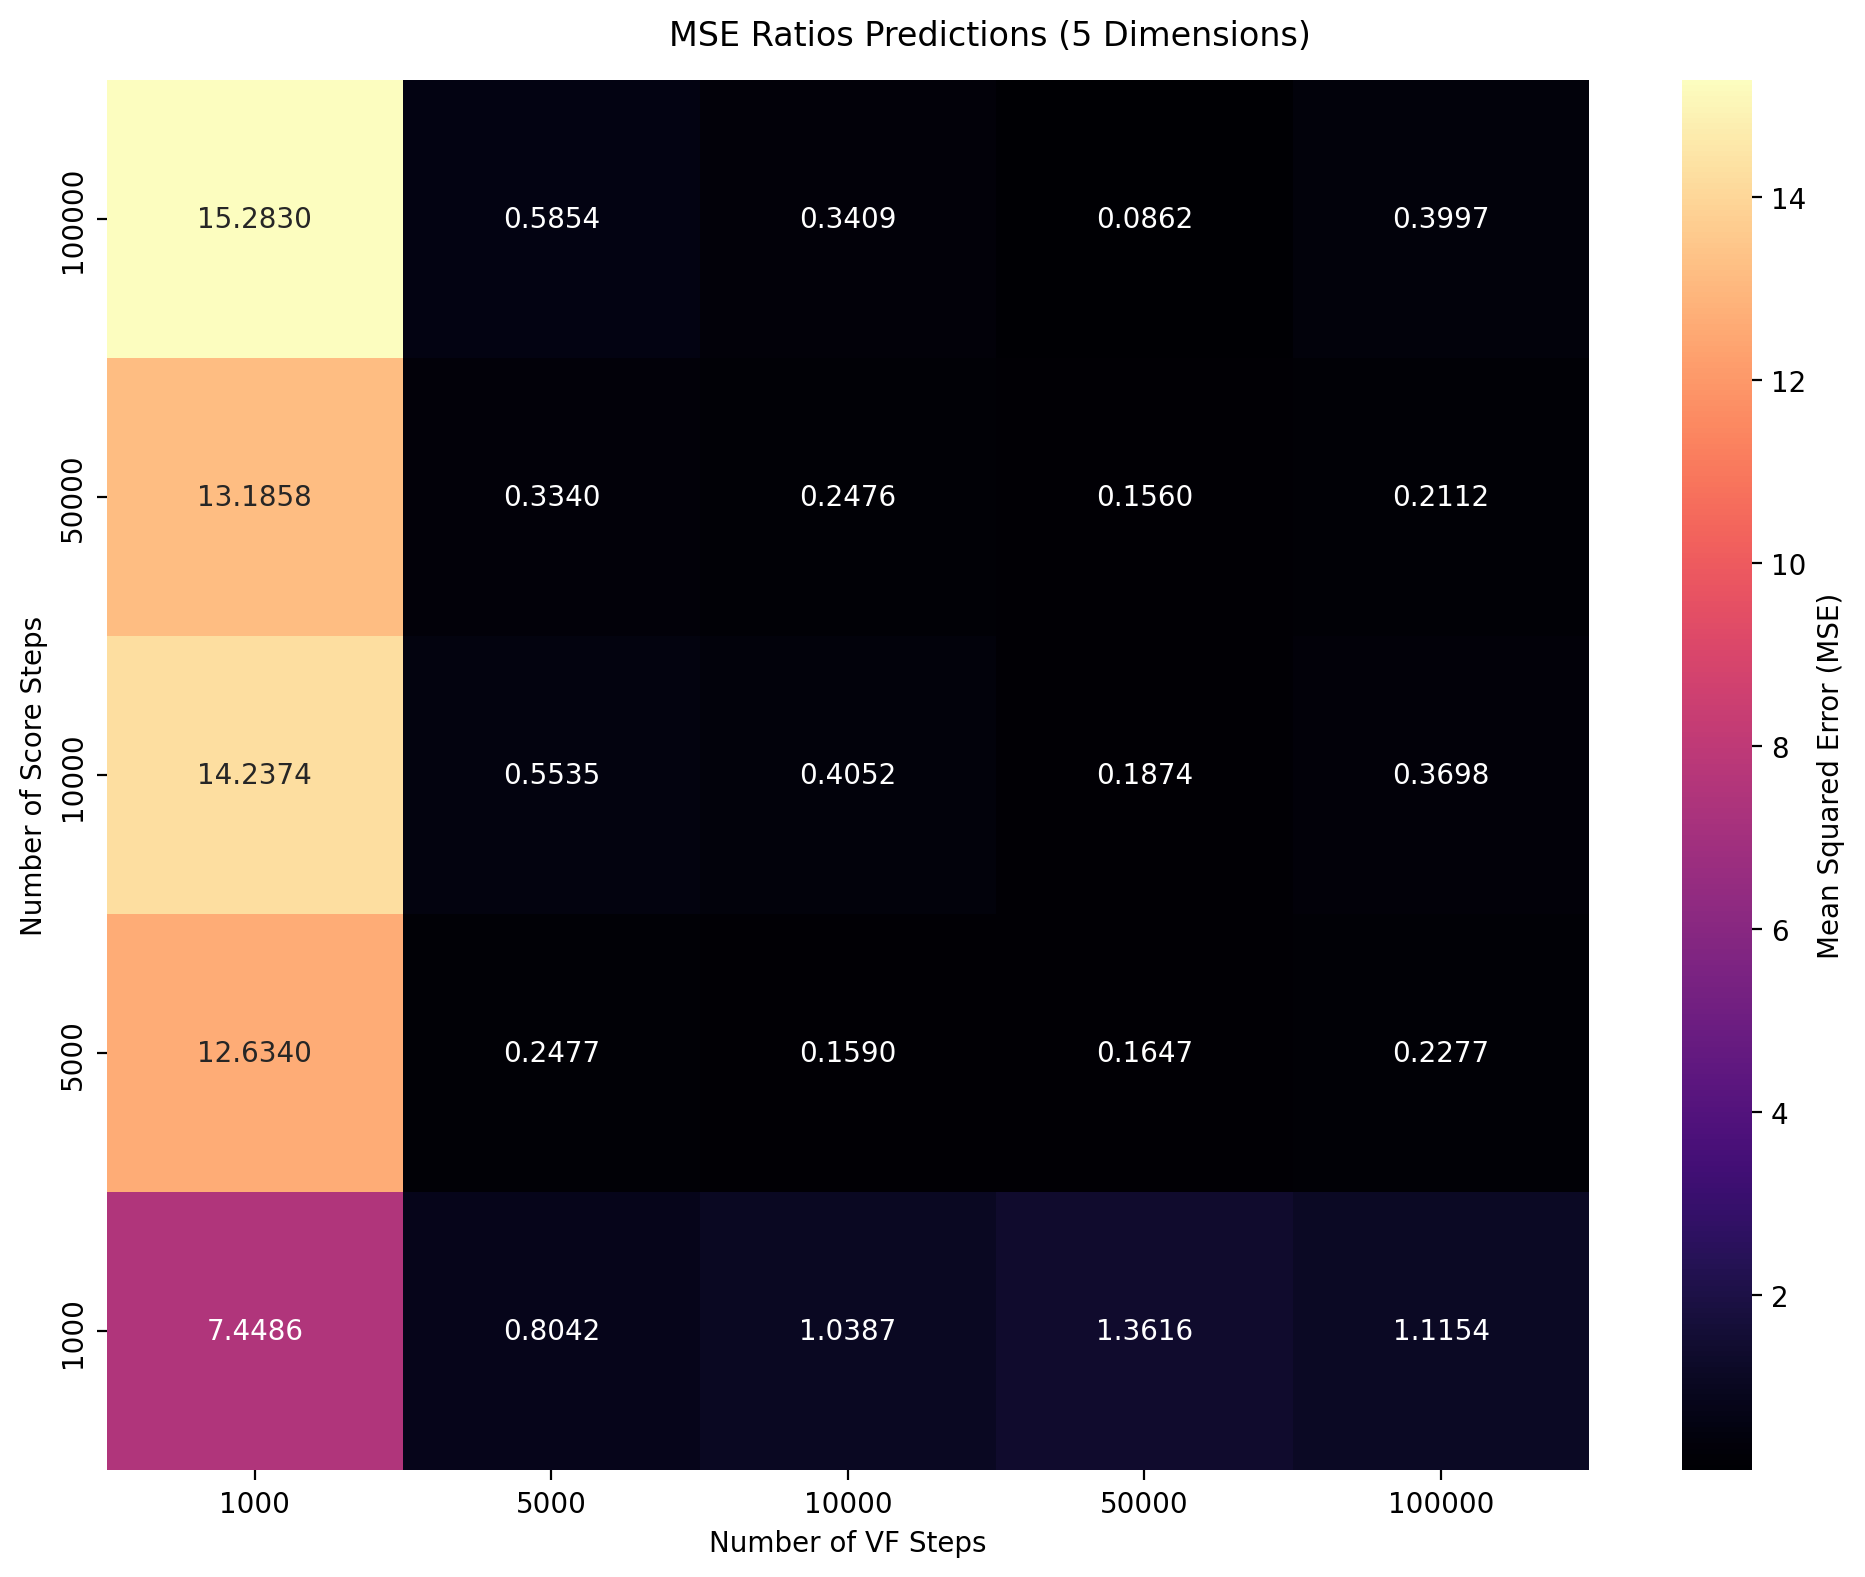

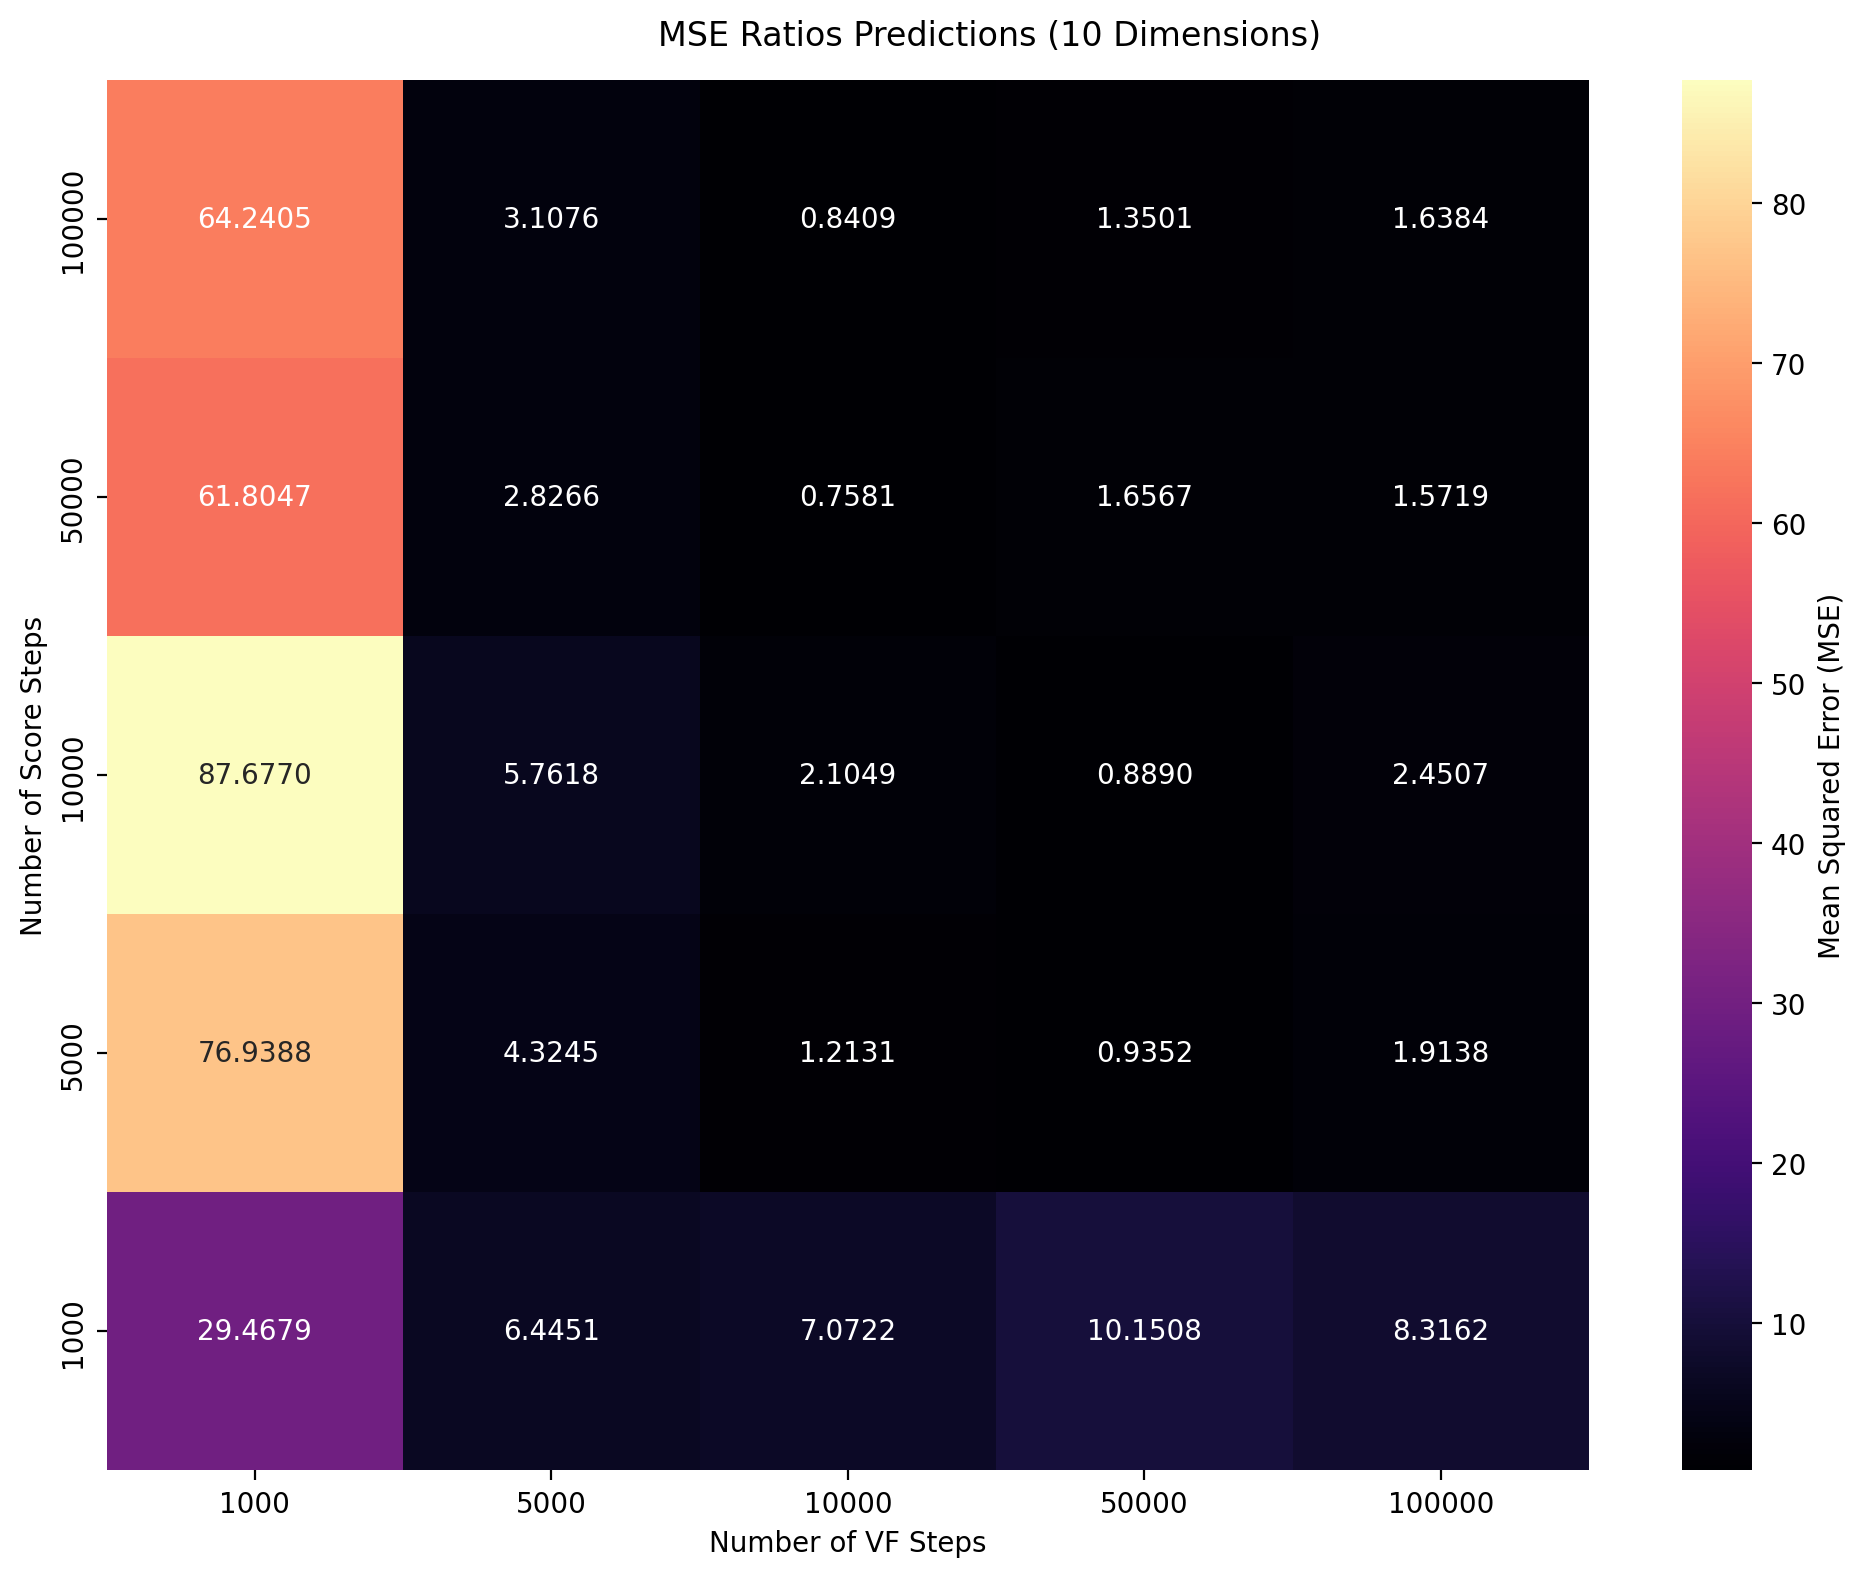

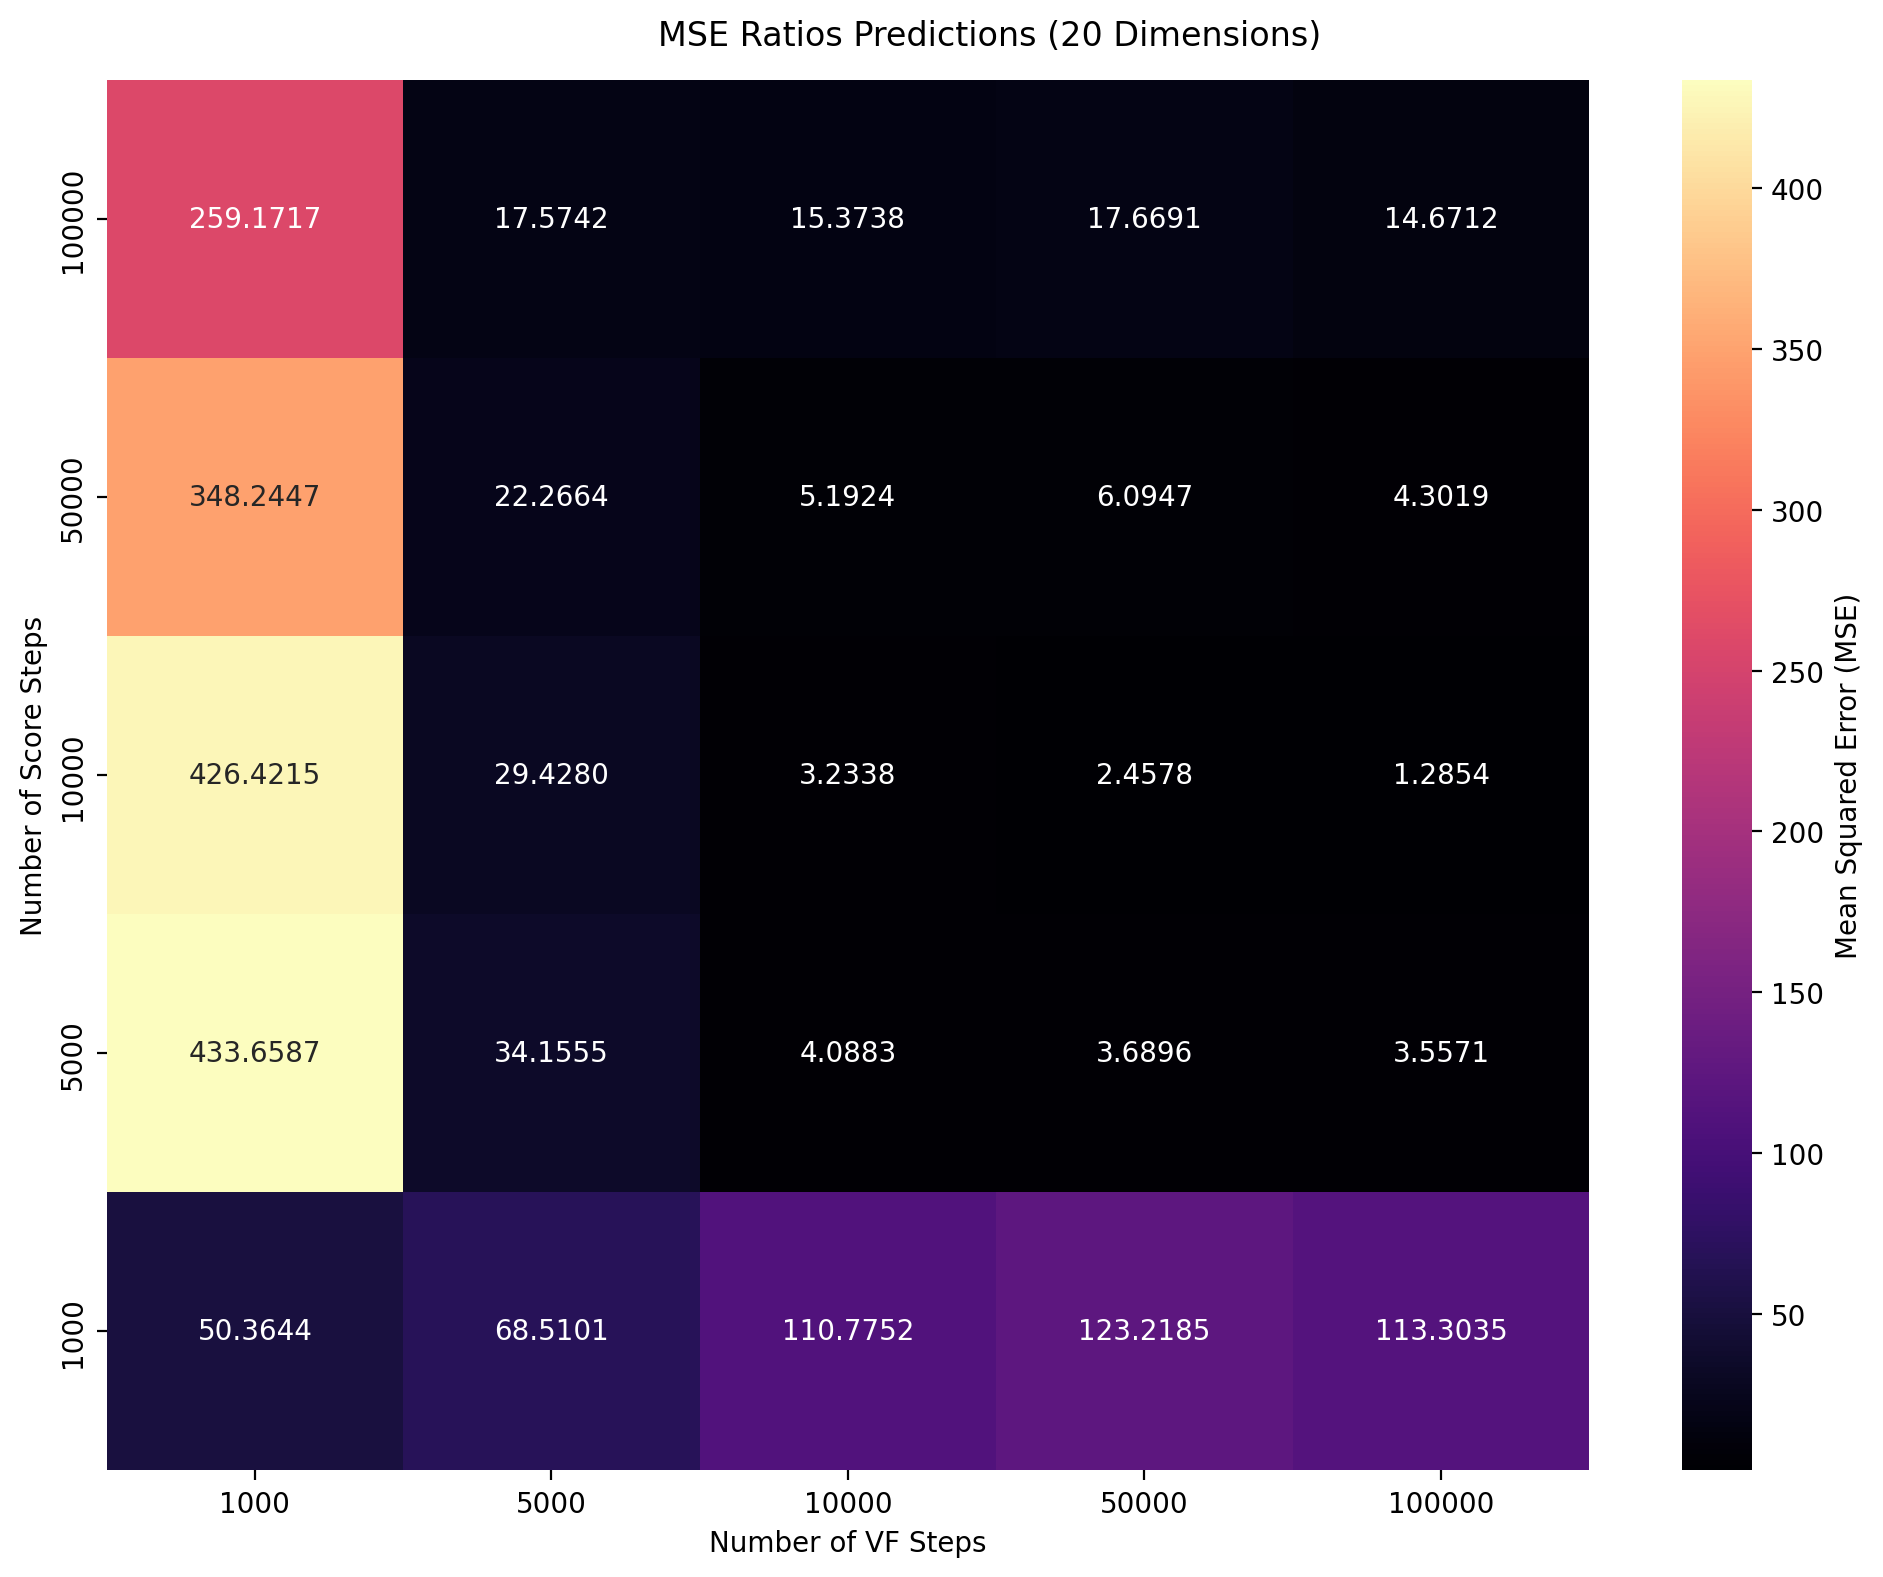

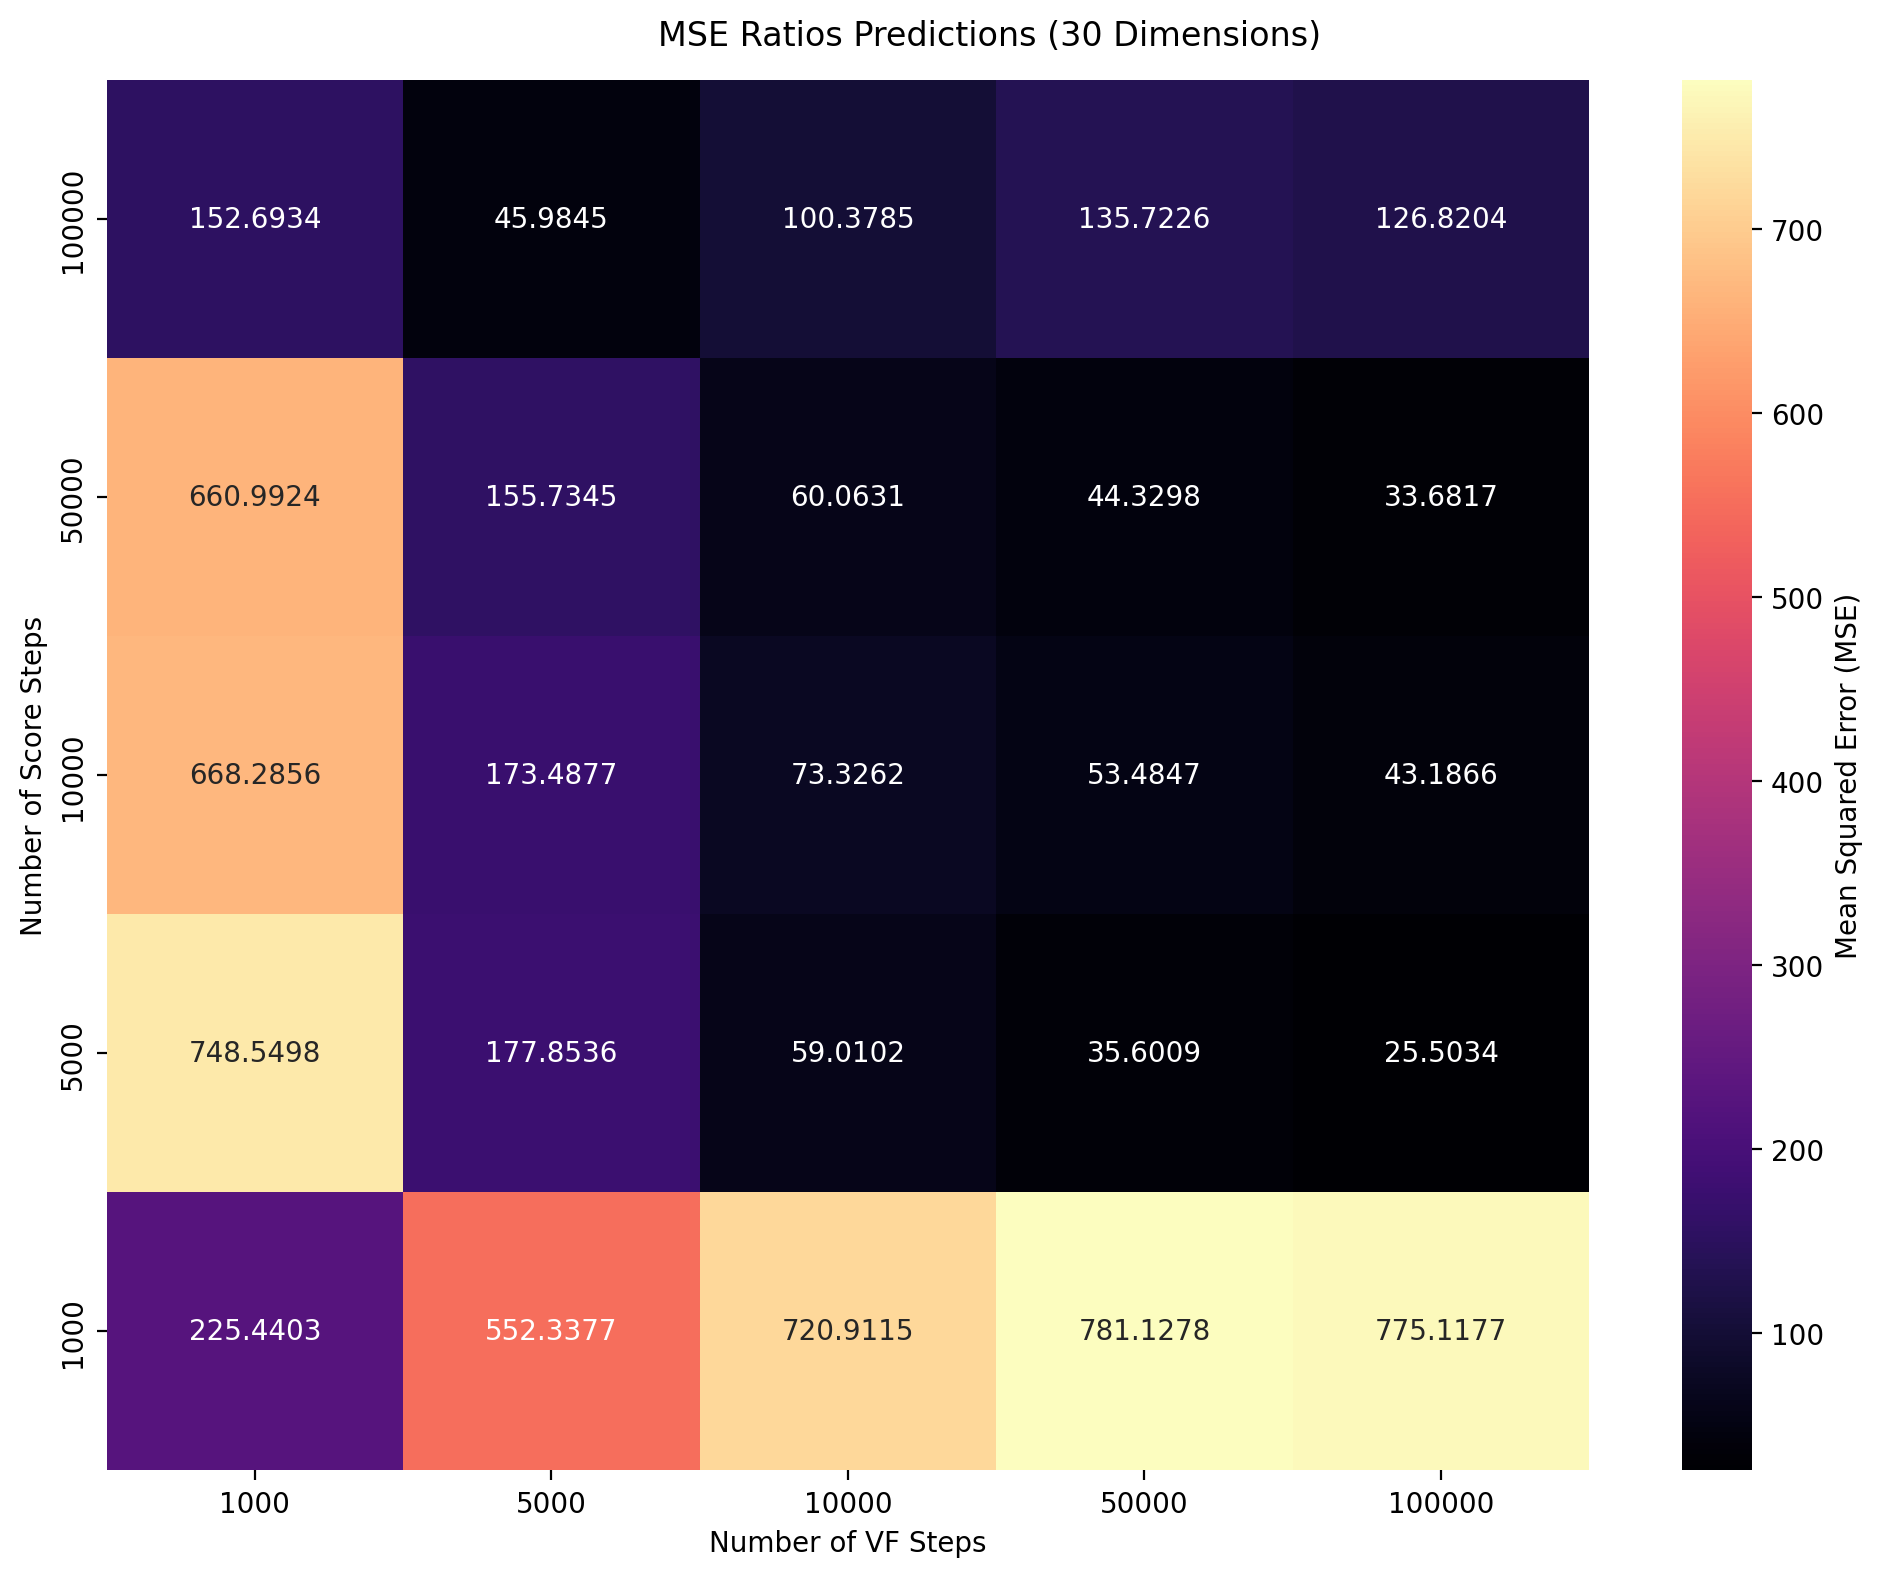

In [23]:
for d in [2, 5, 10, 20, 30]:
    print(d)
    fig, ax = plot_results_per_dim(d)
    fig.savefig(f"/home/icb/lorenzo.consoli/repos/scFM_density_estimation/notebooks/rebuttal_estimation_error_effect/out/{d}-dims-2-loc/plot.svg")